# Data Analysis (B) — Forecaster Explainability: Feature Importance, SHAP Values and Partial Dependence Plots

**This is the implementation and answers for the assignment based on the following source:**  
https://skforecast.org/0.15.1/user_guides/explainability.html

---

This notebook is divided into two parts:
1. **Answers to the analysis questions** (see cells below)
2. **Code implementation** (see cells after the answers)

## Analysis Questions — Answers

---

### 1. What is the prediction analysis about?

This analysis predicts the **total daily electricity demand** in the state of Victoria, Australia. The model estimates how much electricity will be needed in the coming days.

---

### 2. What does the training data look like? (What are the inputs and outputs?)

**Input (X) — Features used by the model:**
- `lag_1` to `lag_7` → electricity demand values from the **past 7 days**
- `Temperature` → average daily temperature for that day

**Output (y) — What is being predicted:**
- `Demand` → total electricity demand for the **next day**

> In short: *"Given the last 7 days of demand and today's temperature, predict tomorrow's electricity demand."*

---

### 3. What is a lag?

A **lag** is a past value of the target variable used as an input to the model.

Example:
- `lag_1` = electricity demand **yesterday**
- `lag_2` = electricity demand **2 days ago**
- `lag_7` = electricity demand **7 days ago**

The idea is that past demand tends to influence future demand. This notebook uses 7 lags (`lags=7`).

---

### 4. Explain the analysis process performed in this case.

The analysis is done in the following order:

1. **Load data** — Download the `vic_electricity` dataset using `fetch_dataset()`, then resample it to daily frequency (sum of Demand, mean of Temperature per day).

2. **Split data** — Split into a training set (up to Dec 21, 2014) and a test set (from Dec 22, 2014 onwards).

3. **Build and train the forecaster** — Create a `ForecasterRecursive` using `LGBMRegressor` as the model, with 7 lags. Trained using Demand as the target and Temperature as an external variable.

4. **Feature Importance** — Check which features (lags + temperature) have the most influence on predictions using `get_feature_importances()`.

5. **SHAP Analysis** — Use SHAP values to explain *why* the model made each prediction. This includes:
   - Summary bar plot (overall feature importance)
   - Beeswarm plot (distribution of SHAP values)
   - Force plot (explanation for a single prediction)
   - Dependence plot (how Temperature affects the prediction)

6. **Make predictions** — Predict the next 10 days of demand using temperature values from the test set.

7. **Permutation Importance** — Another method to measure feature importance by randomly shuffling each feature and observing how much the model accuracy drops.

8. **Partial Dependence Plots (PDP)** — Show how Temperature and `lag_1` individually affect the predicted Demand, while keeping all other features constant.


## Code Implementation

The code below is a direct implementation from the source:  
https://skforecast.org/0.15.1/user_guides/explainability.html

In [1]:
! pip install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.1 MB/s eta 0:00:00


In [2]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

In [3]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


In [4]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


In [5]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test  = data.loc['2014-12-22':]

In [6]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 08:53:34 
Last fit date: 2026-06-10 08:53:34 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [7]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


In [8]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


In [9]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer   = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

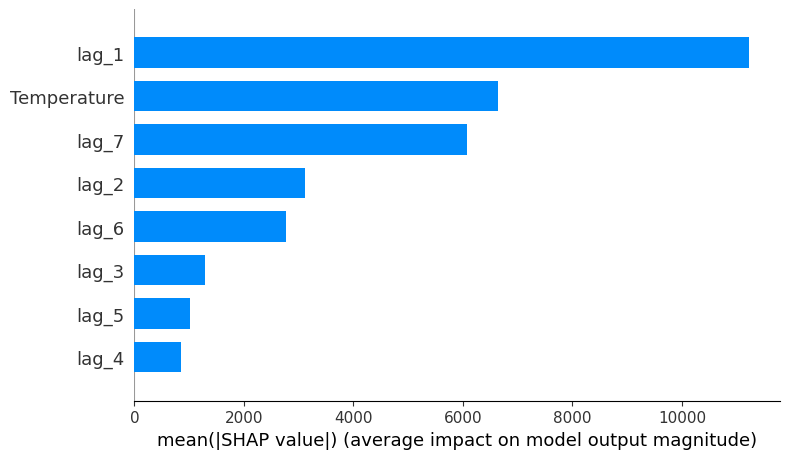

In [10]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

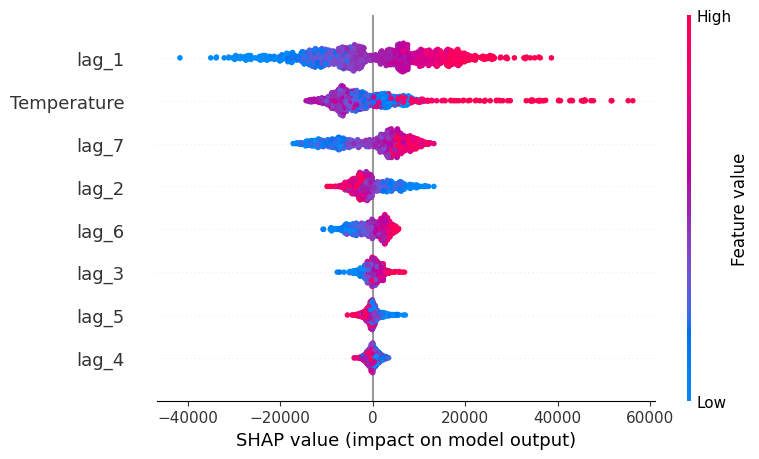

In [11]:
shap.summary_plot(shap_values, X_train)

In [12]:
# Force plot for the first observation
# ==============================================================================
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

In [13]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

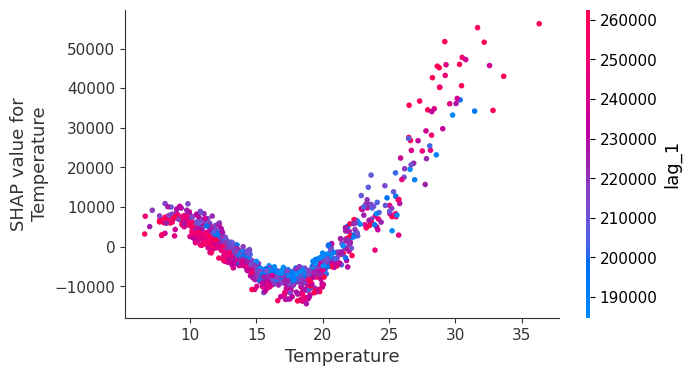

In [14]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

In [15]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


In [16]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


In [17]:
# Force plot for a specific prediction
# ==============================================================================
shap.initjs()
predicted_date       = '2014-12-22'
iloc_predicted_date  = X_predict.index.get_loc(predicted_date)
shap_values          = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

In [18]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.estimator,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature'         : X_train.columns,
                  'mean_importance' : r.importances_mean,
                  'std_importance'  : r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


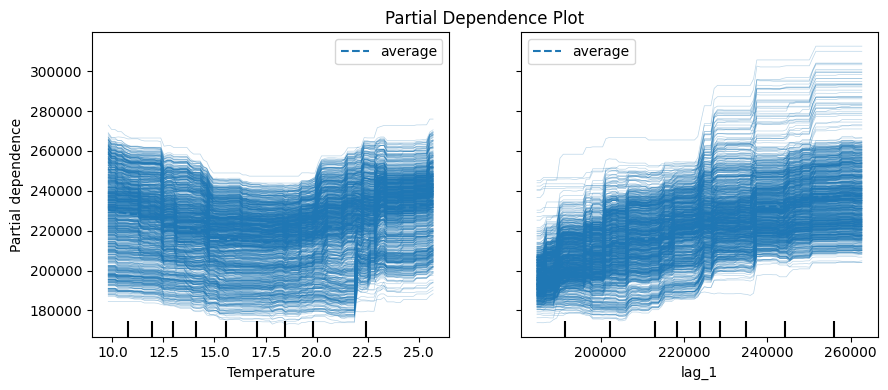

In [19]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd_plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()